# Analyzing MLP Neuron Activations

This notebook analyzes MLP neuron activations from a trained nanoGPT model to explore neuron specialization and semantic properties.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re
from wordcloud import WordCloud
import ipywidgets as widgets
from IPython.display import display, HTML
from scipy.stats import entropy

# Set some visualization defaults
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context("notebook", font_scale=1.2)

## 1. Load and Explore the Data

In [46]:
# Load the activation data
data_path = 'out_base/mlp_activations_base_posttopk_0.0013020833333333333.csv'
df_base = pd.read_csv(data_path)
data_path = 'out/mlp_activations__posttopk_0.0013020833333333333.csv'
df = pd.read_csv(data_path)
# data_path = 'out_8x_sparse/mlp_activations_8x_sparse_posttopk_0.125.csv'
data_path = 'out_8x_sparse/mlp_activations_8x_sparse_posttopk_0.00016276041666666666.csv'
df_8x_sparse = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df['sample_idx'].nunique()}")
print(f"Average sequence length: {df.groupby('sample_idx').size().mean():.1f} tokens")

# Display a sample of the data
df.head()

Dataset shape: (1024000, 52)
Number of samples: 1000
Average sequence length: 1024.0 tokens


,sample_idx,position,token,prompt_prefix,neuron_0:2726,neuron_0:2291,neuron_0:170,neuron_0:1087,neuron_1:282,neuron_1:1855,...,neuron_9:272,neuron_9:1222,neuron_10:865,neuron_10:3004,neuron_10:1485,neuron_10:286,neuron_11:490,neuron_11:2303,neuron_11:385,neuron_11:1865
0,0,0,About,A,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,the,Ab,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,2,author,Abo,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3,:,Abou,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,4,OB,About,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
# Identify neuron columns
neuron_cols = [col for col in df.columns if col.startswith('neuron_')]
print(f"Number of neurons tracked: {len(neuron_cols)}")

# Extract layer information
def extract_layer_info(neuron_cols):
    layers = defaultdict(int)
    for col in neuron_cols:
        match = re.search(r'neuron_(\d+)', col)
        if match:
            layer = int(match.group(1))
            layers[layer] += 1
    return layers

layer_counts = extract_layer_info(neuron_cols)
print("\nNeurons per layer:")
for layer, count in sorted(layer_counts.items()):
    print(f"Layer {layer}: {count} neurons")

Number of neurons tracked: 48

Neurons per layer:
Layer 0: 4 neurons
Layer 1: 4 neurons
Layer 2: 4 neurons
Layer 3: 4 neurons
Layer 4: 4 neurons
Layer 5: 4 neurons
Layer 6: 4 neurons
Layer 7: 4 neurons
Layer 8: 4 neurons
Layer 9: 4 neurons
Layer 10: 4 neurons
Layer 11: 4 neurons


## 2. Analyzing Activation Sparsity

Let's examine how sparse the neuron activations are. Highly sparse activation patterns (where neurons activate strongly for only specific inputs) suggest monosemanticity.

In [48]:
# Calculate activation statistics per neuron
def get_neuron_stats(df):
    neuron_cols = [col for col in df.columns if col.startswith('neuron_')]
    neuron_stats = df[neuron_cols].describe().T
    neuron_stats['abs_mean'] = df[neuron_cols].abs().mean()
    neuron_stats['95th_percentile'] = df[neuron_cols].quantile(0.95)
    neuron_stats['99th_percentile'] = df[neuron_cols].quantile(0.99)

    # Calculate activation rate
    def calc_activation_rate(df, col):
        # threshold = df[col].mean() + 2 * df[col].std()
        threshold = 0
        return (df[col] > threshold).mean() * 100  # Percentage

    neuron_stats['activation_rate'] = [calc_activation_rate(df, col) for col in neuron_cols]
    neuron_stats = neuron_stats.sort_values('activation_rate')

    return neuron_stats

neuron_stats_base = get_neuron_stats(df_base)
neuron_stats = get_neuron_stats(df)
neuron_stats_8x_sparse = get_neuron_stats(df_8x_sparse)

Base model: 44/48 neurons above threshold
Standard model: 40/48 neurons above threshold
8x Sparse model: 27/48 neurons above threshold


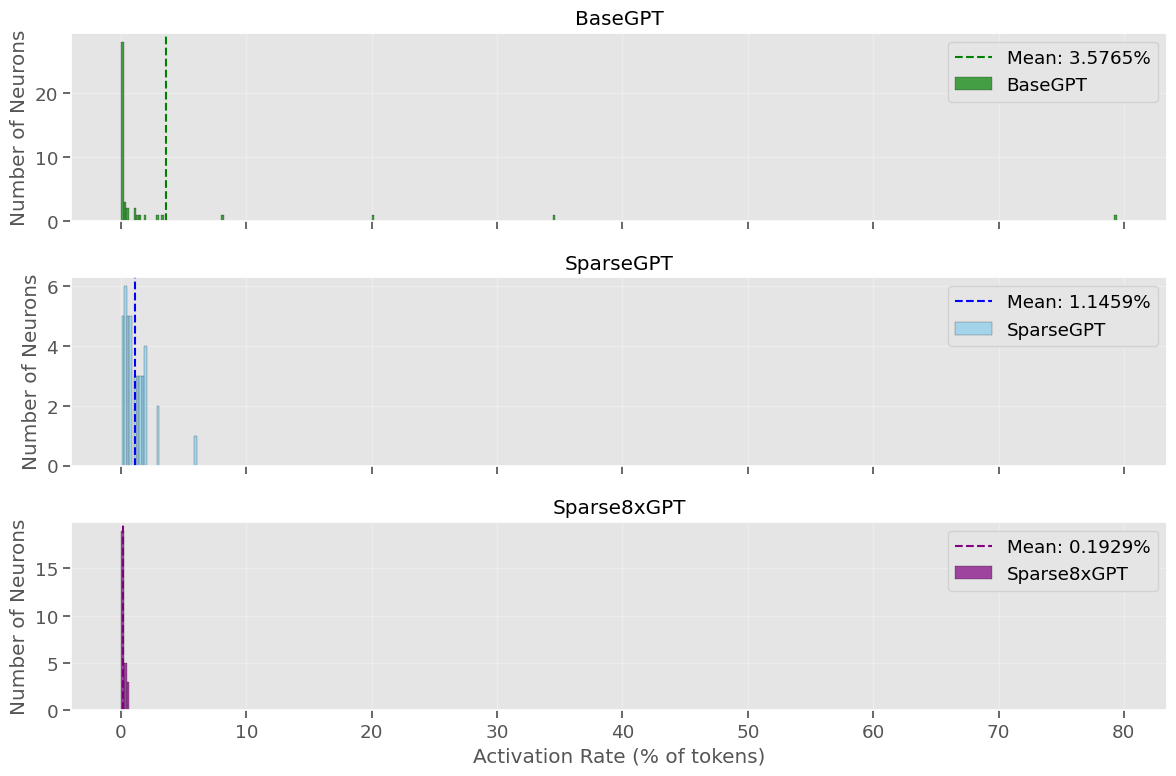

In [92]:
# Improved visualization of neuron activation rates
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from einops import rearrange, reduce

# Create figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Define minimum activation rate to include (filters out extreme outliers)
min_activation_rate = 1e-6  # Adjust this threshold as needed

# Improved histograms with better binning and filtering
# Plot for Base Model
base_activations = neuron_stats_base['activation_rate'].values
filtered_base = base_activations[base_activations >= min_activation_rate]
print(f"Base model: {len(filtered_base)}/{len(base_activations)} neurons above threshold")

sns.histplot(filtered_base, binwidth=0.2, color='green', 
             edgecolor='black', alpha=0.7, label='BaseGPT', ax=axes[0])
axes[0].axvline(filtered_base.mean(), color='green', linestyle='--', 
                label=f'Mean: {filtered_base.mean():.4f}%')
axes[0].set_title('BaseGPT')
axes[0].set_ylabel('Number of Neurons')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# axes[0].set_xscale('log')

# Plot for Standard Model
std_activations = neuron_stats['activation_rate'].values
filtered_std = std_activations[std_activations >= min_activation_rate]
print(f"Standard model: {len(filtered_std)}/{len(std_activations)} neurons above threshold")

sns.histplot(filtered_std, binwidth=0.2, color='skyblue', 
             edgecolor='black', alpha=0.7, label='SparseGPT', ax=axes[1])
axes[1].axvline(filtered_std.mean(), color='blue', linestyle='--', 
                label=f'Mean: {filtered_std.mean():.4f}%')
axes[1].set_title('SparseGPT')
axes[1].set_ylabel('Number of Neurons')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# axes[1].set_xscale('log')

# Plot for 8x Sparse Model
sparse_activations = neuron_stats_8x_sparse['activation_rate'].values
filtered_sparse = sparse_activations[sparse_activations >= min_activation_rate]
print(f"8x Sparse model: {len(filtered_sparse)}/{len(sparse_activations)} neurons above threshold")

sns.histplot(filtered_sparse, binwidth=0.2, color='purple', 
             edgecolor='black', alpha=0.7, label='Sparse8xGPT', ax=axes[2])
axes[2].axvline(filtered_sparse.mean(), color='purple', linestyle='--', 
                label=f'Mean: {filtered_sparse.mean():.4f}%')
axes[2].set_title('Sparse8xGPT')
axes[2].set_xlabel('Activation Rate (% of tokens)')
axes[2].set_ylabel('Number of Neurons')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Finding Monosemantic Neurons

Let's identify neurons that appear most monosemantic (respond strongly to specific types of tokens/concepts).

In [121]:
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import Image

def interactive_neuron_analyzer():
    # Create a single output widget to contain everything
    output_area = widgets.Output()
    
    # Create neuron-sample mapping with min activation > 0 filter
    neuron_sample_options = []
    for neuron in sorted([n for n in neuron_cols if n in low_firing_neurons.index]):
        # Get samples where this neuron has min activation > 0
        neuron_data = df[df[neuron] > 0].groupby('sample_idx')[neuron].min()
        valid_samples = neuron_data[neuron_data > 0].index.tolist()
        
        for sample in sorted(valid_samples):
            neuron_sample_options.append({
                'label': f"{neuron} - Sample {sample}",
                'neuron': neuron,
                'sample': sample
            })
    
    # Create single dropdown for neuron+sample combinations
    selection = widgets.Dropdown(
        options=[(opt['label'], opt) for opt in neuron_sample_options],
        description='Neuron+Sample:',
        style={'description_width': 'initial'}
    )
    
    threshold_slider = widgets.FloatSlider(
        value=0.0,
        min=df[neuron_cols].min().min(),
        max=df[neuron_cols].max().max(),
        step=0.01,
        description='Threshold:',
        style={'description_width': 'initial'}
    )
    
    update_button = widgets.Button(
        description='Update View',
        button_style='primary'
    )
    
    # Layout the controls
    controls = widgets.VBox([
        selection,
        threshold_slider,
        update_button
    ])
    
    # Function to create and display visualization
    def visualize_neuron_activation():
        with output_area:
            clear_output(wait=True)
            display(controls)
            
            # Get parameters
            selected = selection.value
            neuron_col = selected['neuron']
            sample_idx = selected['sample']
            threshold = threshold_slider.value
            
            # Get the sample data
            sample_df = df[df['sample_idx'] == sample_idx].sort_values('position')
            
            if len(sample_df) == 0:
                print(f"Sample {sample_idx} not found in the dataset.")
                return
            
            # Get statistics for this neuron in this sample
            activations = sample_df[neuron_col].values
            max_act = activations.max()
            min_act = activations.min()
            mean_act = activations.mean()
            
            # Count positive activations
            positive_count = (activations > threshold).sum()
            positive_pct = positive_count / len(activations) * 100
            
            # Create HTML visualization
            html_parts = []
            html_parts.append(f"<h3>Sample {sample_idx} - Neuron {neuron_col}</h3>")
            html_parts.append(f"<p>Activation statistics: Min = {min_act:.4f}, Max = {max_act:.4f}, Mean = {mean_act:.4f}</p>")
            html_parts.append(f"<p>Positive activations: {positive_count}/{len(activations)} tokens ({positive_pct:.1f}%)</p>")
            
            html_parts.append("<div style='line-height: 1.7; font-family: monospace; white-space: pre-wrap;'>")
            
            # Create color scale based on activation values
            for _, row in sample_df.iterrows():
                token = row['token']
                activation = row[neuron_col]
                
                # Determine styling based on activation
                if activation > threshold:
                    # Scale color intensity based on how positive the activation is
                    intensity = min(255, int(200 * (activation / max_act)) + 55) if max_act > 0 else 150
                    bg_color = f"rgb(0, {intensity}, 0)"
                    style = f"background-color: {bg_color}; color: white; padding: 2px; border-radius: 3px; margin: 1px;"
                else:
                    # Gray for tokens with activation below threshold
                    intensity = min(230, max(100, int(230 - 100 * (activation / min_act)) if min_act < 0 else 200))
                    style = f"color: rgb({intensity}, {intensity}, {intensity});"
                
                # Add tooltip with exact activation value
                html_parts.append(f"<span style='{style}' title='Activation: {activation:.6f}'>{token}</span>")
            
            html_parts.append("</div>")
            
            # Display the HTML
            display(HTML("".join(html_parts)))
            
            # Plot activation values for each token position
            plt.figure(figsize=(14, 4))
            plt.plot(sample_df['position'], sample_df[neuron_col], marker='o', linestyle='-', color='blue')
            plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
            plt.fill_between(sample_df['position'], sample_df[neuron_col], threshold, 
                           where=(sample_df[neuron_col] > threshold), color='green', alpha=0.3)
            plt.xlabel('Token Position')
            plt.ylabel('Activation Value')
            plt.title(f'Activation Values for Neuron {neuron_col} in Sample {sample_idx}')
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
    
    # Connect update button
    update_button.on_click(lambda b: visualize_neuron_activation())
    
    # Initial display
    display(output_area)
    visualize_neuron_activation()

# Run the interactive analyzer
# interactive_neuron_analyzer()

In [66]:
# Create a dictionary to store activating tokens per neuron
def get_neuron_tokens(df, activation_threshold=0):
    neuron_tokens = {}

    # Iterate through each neuron column
    neuron_cols = [col for col in df.columns if col.startswith('neuron_')]
    from tqdm import tqdm
    from concurrent.futures import ThreadPoolExecutor
    import multiprocessing

    # Define the function to process each neuron column
    def process_neuron(neuron_col):
        # Get tokens where activation exceeds threshold
        activating_tokens = df[df[neuron_col] > activation_threshold][['sample_idx', 'token', neuron_col]].copy()
        
        if not activating_tokens.empty:
            # Sort by activation value descending
            activating_tokens = activating_tokens.sort_values(by="sample_idx", ascending=True)
            return neuron_col, activating_tokens
        return neuron_col, None

    # Use ThreadPoolExecutor for parallelization (works well in Jupyter)
    num_workers = multiprocessing.cpu_count()
    print(f"Using {num_workers} workers for parallel processing")

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(tqdm(executor.map(process_neuron, neuron_cols), total=len(neuron_cols)))

    # Process results
    for neuron_col, tokens in results:
        if tokens is not None:
            neuron_tokens[neuron_col] = tokens

    return neuron_tokens

neuron_tokens = get_neuron_tokens(df)
neuron_tokens_8x_sparse = get_neuron_tokens(df_8x_sparse)
neuron_tokens_base = get_neuron_tokens(df_base)


Using 32 workers for parallel processing


100%|██████████| 48/48 [00:00<00:00, 1036.47it/s]

Using 32 workers for parallel processing



100%|██████████| 48/48 [00:00<00:00, 9174.14it/s]


Using 32 workers for parallel processing


100%|██████████| 48/48 [00:00<00:00, 553.72it/s]


In [67]:
# # Create a dictionary to store activating tokens per neuron
# neuron_tokens = {}

# # Threshold for considering a token as "activating"
# activation_threshold = 0

# # Iterate through each neuron column
# neuron_cols = [col for col in df.columns if col.startswith('neuron_')]
# from tqdm import tqdm
# for neuron_col in tqdm(neuron_cols):
#     # Get tokens where activation exceeds threshold
#     activating_tokens = df[df[neuron_col] > activation_threshold][['sample_idx', 'token', neuron_col]].copy()
    
#     if not activating_tokens.empty:
#         # Sort by activation value descending
#         activating_tokens = activating_tokens.sort_values(by="sample_idx", ascending=True)
#         neuron_tokens[neuron_col] = activating_tokens
# # neuron_tokens


In [69]:
## 4. Measuring Neuron Monosemanticity
import sklearn
# We'll use multiple methods to quantify how semantically coherent each neuron's activations are

import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import numpy as np
from collections import Counter
from scipy.stats import entropy
from einops import rearrange

# Load GPT2 model and tokenizer to access embeddings
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')

# Create a utility function to get embeddings for tokens
def get_embeddings(tokens):
    # Convert tokens to ids safely
    embeddings_list = []
    for token in tokens:
        # Try to encode the token and get its embedding
        token_ids = tokenizer.encode(token, add_special_tokens=False)
        if len(token_ids) > 0:
            # Use the first token id if multiple tokens were returned
            token_id = token_ids[0]
            with torch.no_grad():
                embedding = model.transformer.wte.weight[token_id].numpy()
            embeddings_list.append(embedding)
        else:
            # Use the UNK token embedding if encoding failed
            unk_id = tokenizer.encode('[UNK]', add_special_tokens=False)[0]
            with torch.no_grad():
                embedding = model.transformer.wte.weight[unk_id].numpy()
            embeddings_list.append(embedding)
    
    return np.array(embeddings_list)

# Function to calculate monosemanticity scores
def calculate_monosemanticity_scores(neuron_tokens_dict, min_activations=5):
    results = []
    
    from tqdm.auto import tqdm
    for neuron_id, activations_df in tqdm(neuron_tokens_dict.items(), desc="Calculating monosemanticity scores"):
        # Skip neurons with too few activations
        if len(activations_df) < min_activations:
            continue
            
        # Get unique tokens and their activation values
        tokens = activations_df['token'].values
        activation_values = activations_df[neuron_id].values
        
        # Some tokens might not be processable, so we filter them out
        valid_tokens = []
        valid_activations = []
        for token, activation in zip(tokens, activation_values):
            try:
                # Check if token can be encoded
                if len(tokenizer.encode(token, add_special_tokens=False)) > 0:
                    valid_tokens.append(token)
                    valid_activations.append(activation)
            except:
                # Skip tokens that cause encoding errors
                continue
        
        if len(valid_tokens) < min_activations:
            continue
            
        # Get embeddings
        try:
            valid_tokens = list(dict.fromkeys(valid_tokens))
            embeddings = get_embeddings(valid_tokens)
            
            # 1. Calculate mean pairwise cosine similarity (semantic coherence)
            similarity_matrix = cosine_similarity(embeddings)
            # Remove self-similarity (diagonal)
            np.fill_diagonal(similarity_matrix, 0)
            mean_similarity = similarity_matrix.mean()
            
            # # 2. Calculate activation-weighted mean similarity
            # # This gives more importance to token pairs with higher activations
            # weights = np.outer(valid_activations, valid_activations)
            # weighted_similarity = (similarity_matrix * weights).sum() / weights.sum() if weights.sum() > 0 else 0
            
            # 3. Calculate embedding variance
            # Lower variance suggests tokens are more semantically related
            embedding_variance = np.var(embeddings, axis=0).mean()
            
            # # 4. Calculate activation entropy
            # # Lower entropy suggests the neuron activates more specifically
            # norm_activations = np.array(valid_activations) / sum(valid_activations)
            # activation_entropy = entropy(norm_activations) if len(valid_activations) > 1 else 0
            
            # # 5. Try clustering the embeddings to see if they form distinct groups
            # if len(valid_tokens) >= 5:
            #     kmeans = KMeans(n_clusters=min(3, len(valid_tokens)-1))
            #     clusters = kmeans.fit_predict(embeddings)
            #     cluster_counts = Counter(clusters)
            #     cluster_entropy = entropy(list(cluster_counts.values())) / np.log(len(cluster_counts))
            # else:
            #     cluster_entropy = 1.0  # Maximum entropy if not enough samples
                
            # Store all metrics
            results.append({
                'neuron_id': neuron_id,
                'num_activations': len(valid_tokens),
                'mean_similarity': mean_similarity,
                # 'weighted_similarity': weighted_similarity,
                'embedding_variance': embedding_variance,
                # 'activation_entropy': activation_entropy,
                # 'cluster_entropy': cluster_entropy,
                'monosemanticity_score': mean_similarity / (1 + embedding_variance),  # Combined score
                'top_tokens': ', '.join(valid_tokens[:10])  # Sample of activating tokens
            })
        except Exception as e:
            print(f"Error processing neuron {neuron_id}: {e}")
            continue
    
    # Convert to DataFrame and sort by monosemanticity score
    results_df = pd.DataFrame(results).sort_values('monosemanticity_score', ascending=False)
    return results_df

# Calculate monosemanticity scores for our neurons
monosemanticity_scores = calculate_monosemanticity_scores(neuron_tokens, min_activations=5)
monosemanticity_scores_8x_sparse = calculate_monosemanticity_scores(neuron_tokens_8x_sparse, min_activations=5)
monosemanticity_scores_base = calculate_monosemanticity_scores(neuron_tokens_base, min_activations=5)
# save_path = 'monosemanticity_scores_baseact_posttopk_all.csv'
# save_path = 'monosemanticity_scores_8x_sparse_posttopk_0.125.csv'
# monosemanticity_scores.to_csv(save_path, index=False)
# print(f"Monosemanticity scores saved to '{save_path}'")

# Create a visualization function to explore the most monosemantic neurons
def explore_monosemantic_neurons():
    neuron_dropdown = widgets.Dropdown(
        options=monosemanticity_scores['neuron_id'].tolist(),
        description='Select Neuron:',
        style={'description_width': 'initial'}
    )
    
    output = widgets.Output()
    
    def on_neuron_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            neuron_id = change['new']
            with output:
                clear_output(wait=True)
                
                # Get neuron metrics
                neuron_data = monosemanticity_scores[monosemanticity_scores['neuron_id'] == neuron_id].iloc[0]
                
                # Display neuron information
                print(f"Analyzing neuron: {neuron_id}")
                print(f"Monosemanticity score: {neuron_data['monosemanticity_score']:.4f}")
                print(f"Mean similarity: {neuron_data['mean_similarity']:.4f}")
                print(f"Embedding variance: {neuron_data['embedding_variance']:.4f}")
                print(f"Number of activations: {neuron_data['num_activations']}")
                
                # Get tokens that activate this neuron
                activating_df = neuron_tokens[neuron_id].sort_values(neuron_id, ascending=False)
                
                # Display top activating tokens
                print("\nTop 20 activating tokens:")
                for idx, row in activating_df.head(20).iterrows():
                    print(f"  {row['token']}: {row[neuron_id]:.4f}")
                
                # Get embeddings for visualization
                top_tokens = activating_df.head(min(50, len(activating_df)))['token'].tolist()
                valid_tokens = []
                for token in top_tokens:
                    try:
                        # Check if token can be encoded
                        if len(tokenizer.encode(token, add_special_tokens=False)) > 0:
                            valid_tokens.append(token)
                    except:
                        # Skip tokens that cause encoding errors
                        continue
                
                if len(valid_tokens) >= 3:
                    # Get embeddings and reduce dimensionality for visualization
                    from sklearn.decomposition import PCA
                    embeddings = get_embeddings(valid_tokens)
                    pca = PCA(n_components=2)
                    reduced_embeddings = pca.fit_transform(embeddings)
                    
                    # Plot in 2D space
                    plt.figure(figsize=(10, 8))
                    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                                alpha=0.7, s=100, c='steelblue')
                    
                    # Add token labels
                    for i, token in enumerate(valid_tokens):
                        plt.annotate(token, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), 
                                    fontsize=9, alpha=0.8)
                    
                    plt.title(f'Embedding Space of Tokens Activating {neuron_id}')
                    plt.xlabel('PCA Dimension 1')
                    plt.ylabel('PCA Dimension 2')
                    plt.grid(alpha=0.3)
                    plt.show()
                
                # Create wordcloud of activating tokens weighted by activation
                from wordcloud import WordCloud
                if len(activating_df) > 5:
                    # Create dictionary of token:activation pairs
                    word_dict = dict(zip(activating_df['token'].values, activating_df[neuron_id].values))
                    
                    # Generate and display wordcloud
                    wordcloud = WordCloud(width=800, height=400, background_color='white',
                                         colormap='viridis', max_words=100).generate_from_frequencies(word_dict)
                    
                    plt.figure(figsize=(12, 6))
                    plt.imshow(wordcloud, interpolation='bilinear')
                    plt.axis('off')
                    plt.title(f'WordCloud for Neuron {neuron_id}')
                    plt.show()
    
    neuron_dropdown.observe(on_neuron_change, names='value')
    
    # Trigger initial display
    on_neuron_change({'type': 'change', 'name': 'value', 'new': neuron_dropdown.value})
    
    # Layout widgets
    return widgets.VBox([neuron_dropdown, output])

# # Create interactive visualization
# explore_widget = explore_monosemantic_neurons()
# display(explore_widget)

Calculating monosemanticity scores:   0%|          | 0/40 [00:00<?, ?it/s]

Calculating monosemanticity scores:   0%|          | 0/27 [00:00<?, ?it/s]

Calculating monosemanticity scores:   0%|          | 0/44 [00:00<?, ?it/s]

In [9]:
# Set pandas display options to show more rows
pd.set_option('display.max_rows', 120)


Average monosemanticity score for BaseGPT: 0.2514
Average monosemanticity score for SparseGPT: 0.2459
Average monosemanticity score for Sparse8xGPT: 0.2519


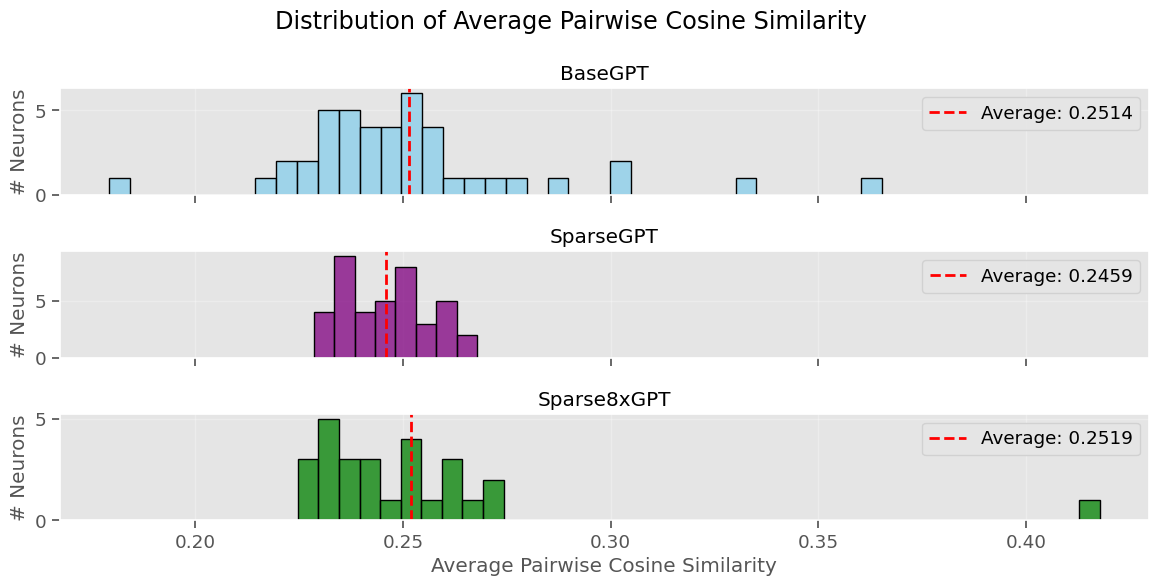

In [85]:
# Create a visualization comparing monosemanticity scores across models
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Model labels for clarity
model_names = ['BaseGPT', 'SparseGPT', 'Sparse8xGPT']
datasets = [monosemanticity_scores_base, monosemanticity_scores, monosemanticity_scores_8x_sparse]
colors = ['skyblue', 'purple', 'green']

# Plot each model's distribution
for i, (ax, data, name, color) in enumerate(zip(axes, datasets, model_names, colors)):
    # Plot histogram
    sns.histplot(data['monosemanticity_score'], binwidth=0.005, color=color, edgecolor='black', ax=ax)
    
    # Calculate and display average score
    avg_score = data['monosemanticity_score'].mean()
    print(f"Average monosemanticity score for {name}: {avg_score:.4f}")
    
    # Add vertical line for mean
    ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, 
              label=f'Average: {avg_score:.4f}')
    
    # Set labels and title
    ax.set_title(f'{name}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylabel('# Neurons')

fig.suptitle('Distribution of Average Pairwise Cosine Similarity')
# Set x and y labels on the figure - need to use the figure's axes
plt.xlabel('Average Pairwise Cosine Similarity')


# Adjust layout
plt.tight_layout()
plt.show()

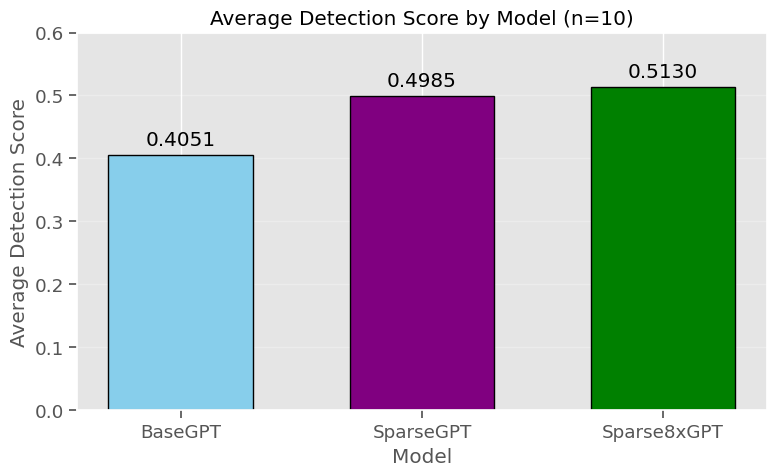

Average monosemanticity score for BaseGPT: 0.4051
Average monosemanticity score for SparseGPT: 0.4985
Average monosemanticity score for Sparse8xGPT: 0.5130


In [96]:
# Create a bar chart comparing average monosemanticity scores across models
plt.figure(figsize=(8, 5))

# Data for the bar chart
models = ['BaseGPT', 'SparseGPT', 'Sparse8xGPT']
scores = [0.40512820512820513, 0.4985042735042734, 0.513]
colors = ['skyblue', 'purple', 'green']

# Create the bar chart
bars = plt.bar(models, scores, color=colors, edgecolor='black', width=0.6)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom')

# Add labels and title
plt.title('Average Detection Score by Model (n=10)')
plt.xlabel('Model')
plt.ylabel('Average Detection Score')
plt.ylim(0, 0.6)  # Set y-axis limit to make the differences more visible
plt.grid(True, alpha=0.3, axis='y')

# Display the chart
plt.tight_layout()
plt.show()

# Print the values
for model, score in zip(models, scores):
    print(f"Average monosemanticity score for {model}: {score:.4f}")

,neuron_id,num_activations,mean_similarity,monosemanticity_score,top_tokens
32,neuron_8:559,21,0.368032,0.365225,"conducted, amended, 118, 170, 178, 170, ..."
17,neuron_4:726,23,0.335545,0.333086,"it, she, that, who, this, there, they, ..."
30,neuron_8:2131,29,0.306631,0.304051,"their, no, your, there, a, the, this, ..."
14,neuron_4:2700,35,0.303758,0.301186,"So, several, Thousand, ($, went, ousand, m..."
18,neuron_5:1332,209,0.289929,0.286038,"organizations, maps, crops, comes, splits,..."
23,neuron_6:2611,164,0.280494,0.277380,"1956, Japanese, German, 1954, real, Fran..."
26,neuron_7:255,4,0.272897,0.271529,"over, on, to, baseball"
25,neuron_6:1642,19,0.270486,0.267951,"Except, Finally, damn, Of, of, note, yo..."
22,neuron_6:1083,78,0.263229,0.260730,"name, work, age, real, ubiquitous, than,..."
33,neuron_9:527,2335,0.260413,0.257094,"you, …, it, ., banks, years, voters, and..."


Average monosemanticity score: 0.2514


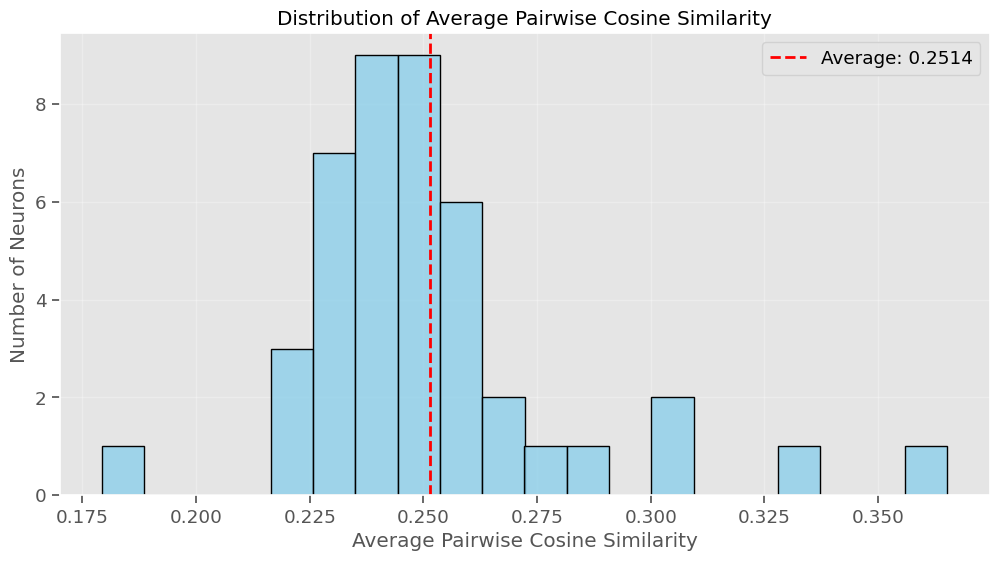

In [33]:
display(monosemanticity_scores.head(99)[['neuron_id', 'num_activations', 'mean_similarity', 
                               'monosemanticity_score', 'top_tokens']])

# Visualize the distribution of monosemanticity scores
plt.figure(figsize=(12, 6))
sns.histplot(monosemanticity_scores['monosemanticity_score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Average Pairwise Cosine Similarity')
plt.xlabel('Average Pairwise Cosine Similarity')
plt.ylabel('Number of Neurons')
# Calculate the average monosemanticity score
avg_score = monosemanticity_scores['monosemanticity_score'].mean()
print(f"Average monosemanticity score: {avg_score:.4f}")

# Add a vertical line at the average score
plt.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, 
            label=f'Average: {avg_score:.4f}')
plt.legend()

plt.grid(True, alpha=0.3)
# plt.xlim(0, 1)
plt.show()

,neuron_id,num_activations,mean_similarity,monosemanticity_score,top_tokens
32,neuron_8:559,21,0.368032,0.365225,"conducted, amended, 118, 170, 178, 170, ..."
17,neuron_4:726,23,0.335545,0.333086,"it, she, that, who, this, there, they, ..."
30,neuron_8:2131,29,0.306631,0.304051,"their, no, your, there, a, the, this, ..."
14,neuron_4:2700,35,0.303758,0.301186,"So, several, Thousand, ($, went, ousand, m..."
18,neuron_5:1332,209,0.289929,0.286038,"organizations, maps, crops, comes, splits,..."
23,neuron_6:2611,164,0.280494,0.277380,"1956, Japanese, German, 1954, real, Fran..."
26,neuron_7:255,4,0.272897,0.271529,"over, on, to, baseball"
25,neuron_6:1642,19,0.270486,0.267951,"Except, Finally, damn, Of, of, note, yo..."
22,neuron_6:1083,78,0.263229,0.260730,"name, work, age, real, ubiquitous, than,..."
33,neuron_9:527,2335,0.260413,0.257094,"you, …, it, ., banks, years, voters, and..."


Average monosemanticity score: 0.2514


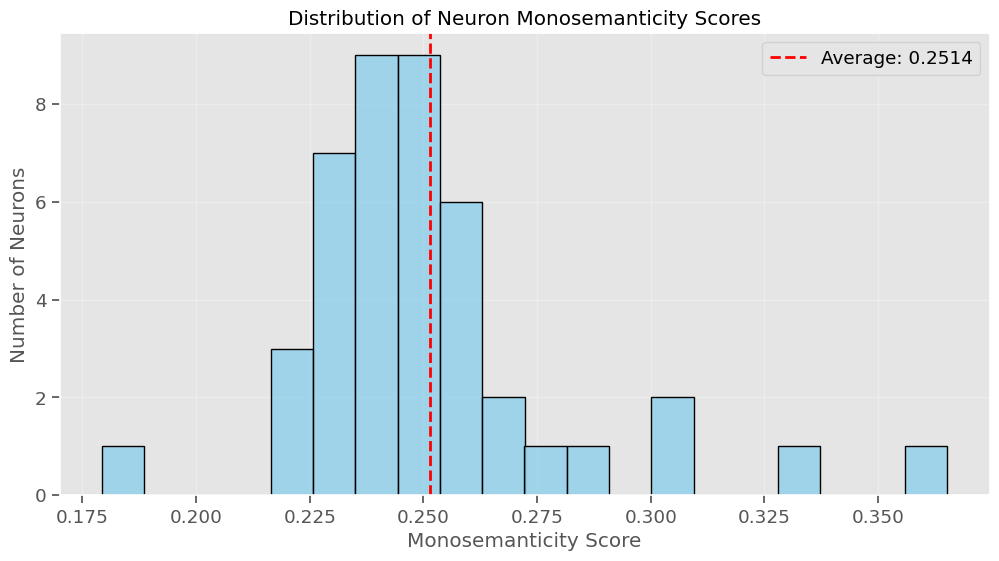

In [20]:
display(monosemanticity_scores.head(99)[['neuron_id', 'num_activations', 'mean_similarity', 
                               'monosemanticity_score', 'top_tokens']])

# Visualize the distribution of monosemanticity scores
plt.figure(figsize=(12, 6))
sns.histplot(monosemanticity_scores['monosemanticity_score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Neuron Monosemanticity Scores')
plt.xlabel('Monosemanticity Score')
plt.ylabel('Number of Neurons')
# Calculate the average monosemanticity score
avg_score = monosemanticity_scores['monosemanticity_score'].mean()
print(f"Average monosemanticity score: {avg_score:.4f}")

# Add a vertical line at the average score
plt.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, 
            label=f'Average: {avg_score:.4f}')
plt.legend()

plt.grid(True, alpha=0.3)
# plt.xlim(0, 1)
plt.show()

count    16116.000000
mean         0.731432
std          0.182074
min          0.019000
25%          0.625731
50%          0.769226
75%          0.868036
max          1.000000
Name: cluster_entropy, dtype: float64


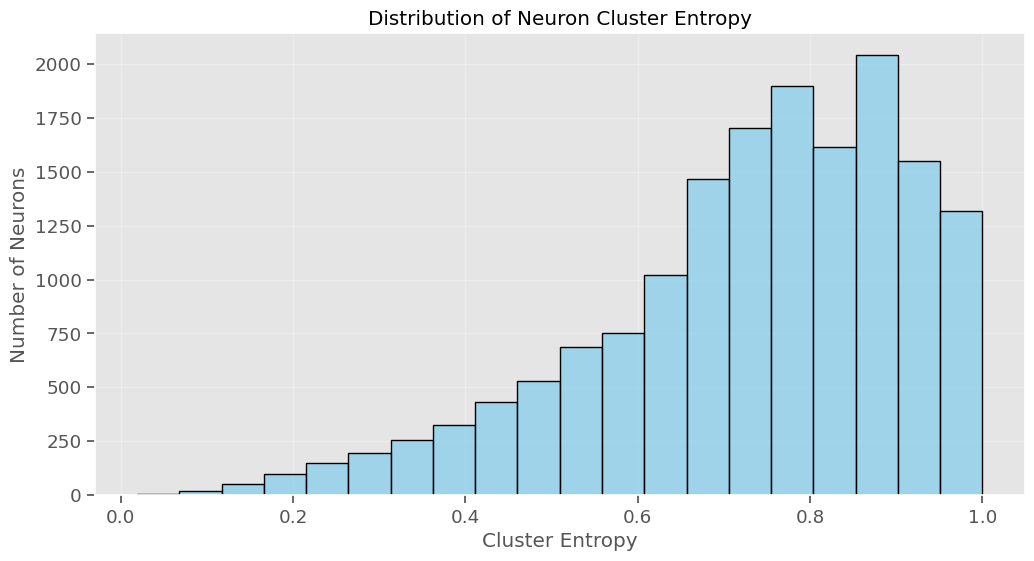

In [131]:
# Display statistics of cluster entropy
print(monosemanticity_scores.cluster_entropy.describe())

# Plot histogram of cluster entropy
plt.figure(figsize=(12, 6))
sns.histplot(monosemanticity_scores['cluster_entropy'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Neuron Cluster Entropy')
plt.xlabel('Cluster Entropy')
plt.ylabel('Number of Neurons')
plt.grid(True, alpha=0.3)
plt.show()